
# Statistics

In [69]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom, poisson, geom


In [7]:
# mean which is the average value of the data
values = [3, 11, 4, 5, 23]
print(np.mean(values))

9.2


In [17]:
# The median is the middle value in a data set ordered from low to high.
values = [13,21,21,40,42,48,55,72] # even elements
print(np.median(values))
values1 = [13,21,21,40,42,48,55,58,72] # odd elements
print(np.median(values1))

41.0
42.0


In [21]:
from statistics import mode, multimode, kde

# Mode is value that appears most frequently in a dataset.
# A distribution of values with only one mode is called unimodal.
# A distribution of values with two modes is called bimodal.
# In general, a distribution with more than one mode is called multimodal.
values = [4,7,3,8,11,7,10,19,6,9,12,12]
print(mode(values))
print(multimode(values))

7
[7, 12]


In [23]:
# The range is the difference between the smallest and the largest value of the data.
values = [13,21,21,40,48,55,72]
print(np.ptp(values))

59


In [25]:
# Interquartile range is the difference between the first and third quartiles (Q1 and Q3).
from scipy import stats
values = [13,21,21,40,42,48,55,72]
print(stats.iqr(values))

28.75


In [27]:
# Standard deviation measures how spread out the data is from the mean.
values = [13,21,21,40,42,48,55,72]
print(np.std(values)) # for population n
print(np.std(values, ddof=1)) # for sample, (n - 1)

18.57417562100671
19.85662897587892


## Normal Distribution
he Normal Distribution is one of the most important distributions.

It is also called the Gaussian Distribution after the German mathematician Carl Friedrich Gauss.

It fits the probability distribution of many events, eg. IQ Scores, Heartbeat etc.

Use the `random.normal()` method to get a Normal Data Distribution.

It has three parameters:

`loc` (mean), `scale` (standard deviation), `size` (the shape)

In [112]:
# Generate a random normal distribution of size 2x3, mean at zero and st of 1
# 95% of values fall between [−2 to +2]
x = random.normal(size=(2, 3))
print(x)

[[ 0.55982805 -0.56508407 -0.34416201]
 [ 0.20028196  0.27105545 -0.13687152]]


In [83]:
# Generate a random normal distribution of size 2x3, mean at 1 and st of 2
# 95% of values fall between [−3 to +5]
x = random.normal(loc=1, scale=2, size=(2, 3))
print(x)

[[ 1.48784209  2.71950077 -0.4587939 ]
 [-0.44410567  1.51428467  1.53249048]]


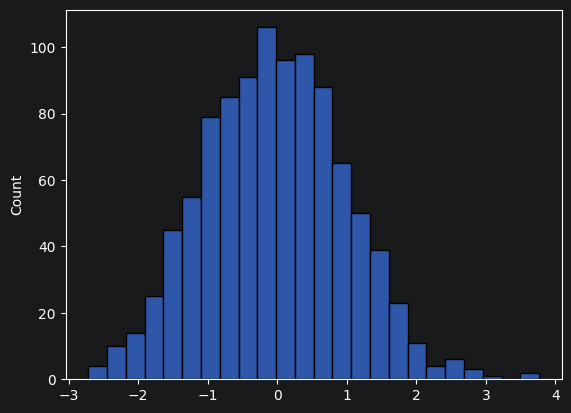

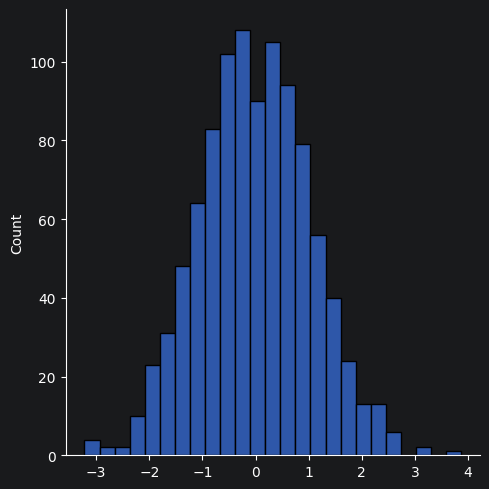

In [127]:
# visualization of Normal Distribution in histogram in two ways
sns.histplot(random.normal(size=1000))
sns.displot(random.normal(size=1000), kind="hist")
plt.show()

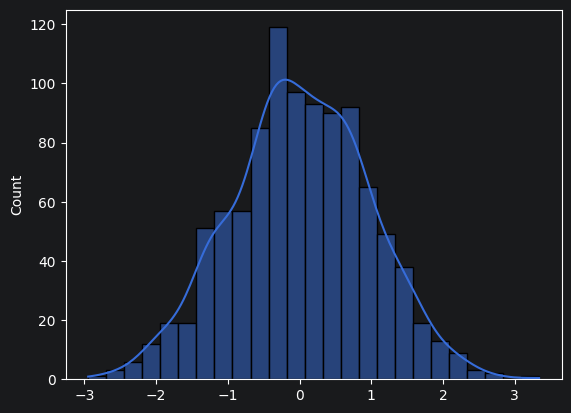

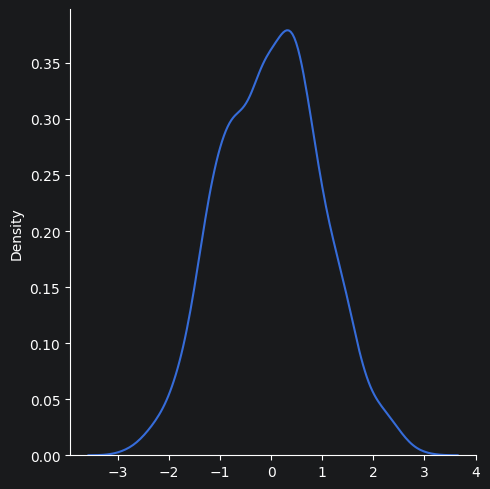

In [126]:
sns.histplot(random.normal(size=1000), kde=True) # kde, smooth curve
sns.displot(random.normal(size=1000), kind="kde")
plt.show()

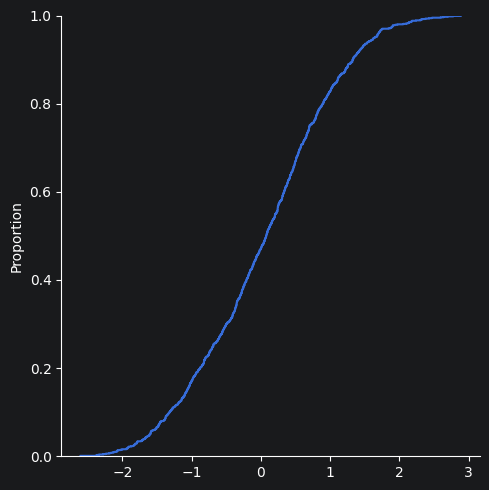

In [130]:
sns.displot(random.normal(size=1000), kind="ecdf") # cumulative distribution
plt.show()

## Binomial Distribution
Binomial Distribution is a Discrete Distribution.

It describes the outcome of binary scenarios, e.g. toss of a coin, it will either be head or tails.

It has three parameters:

`n` - number of trials.

`p` - probability of occurrence of each trial (e.g. for toss of a coin 0.5 each).

`size` - The shape of the returned array.

In [28]:
"""
n=10 → each trial has 10 coin flips
p=0.5 → probability of success (heads) = 50%
size=10 → repeat the whole experiment 10 times
"""
# each value from size = sum of n experiments (how many heads in 10 flips)
x = random.binomial(n=10, p=0.5, size=10)
print(x)

[5 3 5 2 4 4 3 4 3 4]


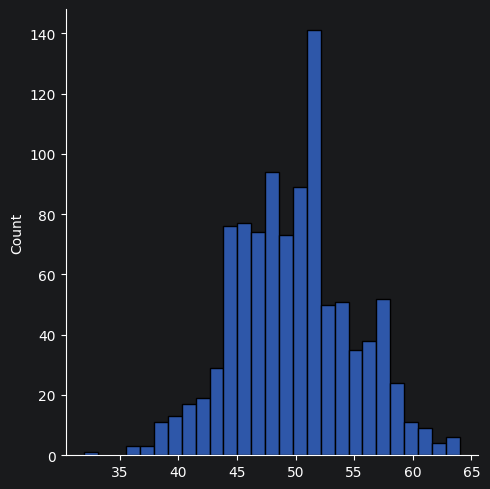

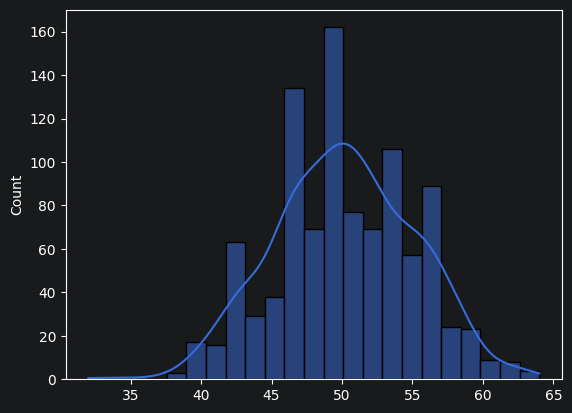

In [46]:
# Visualization of Binomial Distribution
sns.displot(random.binomial(n=100, p=0.5, size=1000))
plt.show()
sns.histplot(random.binomial(n=100, p=0.5, size=1000), kde=True)
plt.show()


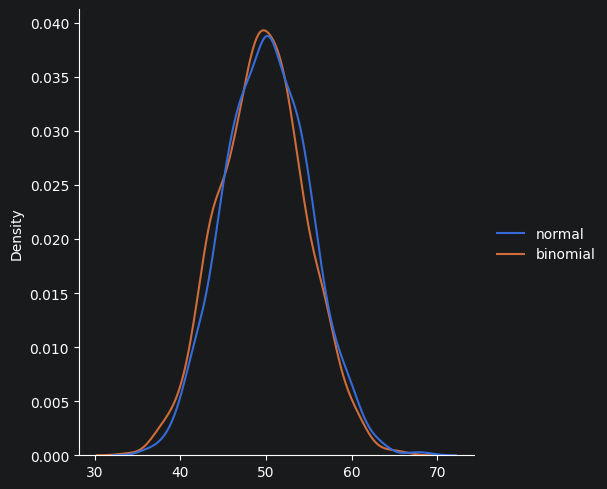

In [44]:
"""
The main difference is that normal distribution is continuous whereas binomial is discrete,
but if there are enough data points it will be quite similar to normal distribution with
 certain loc and scale.
"""
data = {
  "normal": random.normal(loc=50, scale=5, size=1000),
  "binomial": random.binomial(n=100, p=0.5, size=1000)
}

sns.displot(data, kind="kde")

plt.show()

### Geometric Distribution
Geometric Distribution is a Discrete Distribution.
It describes how many trials are needed to get the first success, e.g. how many coin tosses until you get heads.

It has two parameters:

`p` — probability of success per trial<br>
`size` — shape of the returned array

In [49]:
# Generate 10 data points:
# Each number = how many flips it took to get the first head.
x = random.geometric(p=0.5, size=10)
print(x)

[3 5 9 4 5 3 6 8 1 9]


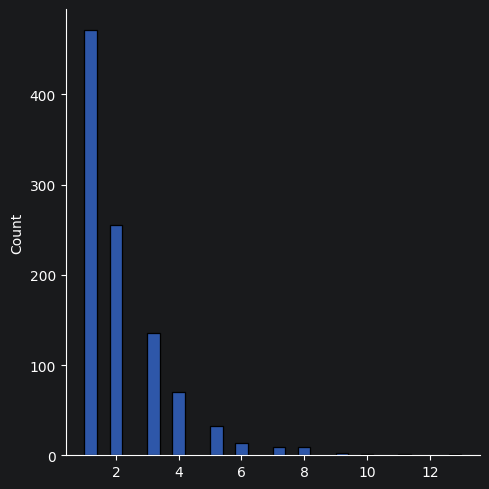

In [53]:
# Visualization of Geometric Distribution:
sns.displot(random.geometric(p=0.5, size=1000))
plt.show()

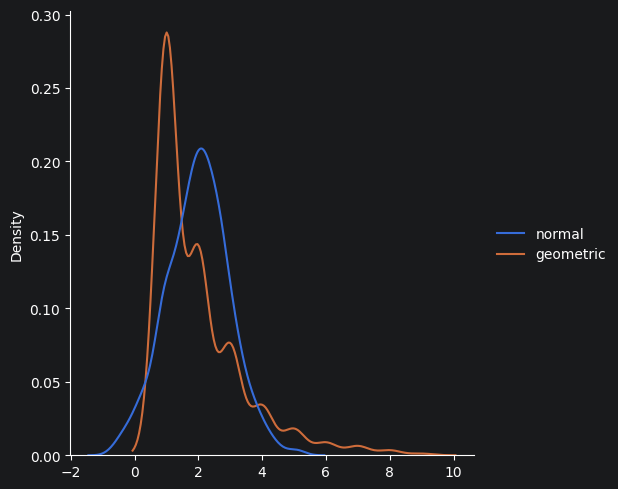

In [50]:
"""The main difference is that normal distribution is continuous whereas geometric is discrete. Geometric is also always right skewed (long tail to the right) because small values (success on trial 1 or 2) are most common."""

data = {
  "normal": random.normal(loc=2, scale=1, size=1000),
  "geometric": random.geometric(p=0.5, size=1000)
}

sns.displot(data, kind="kde")

plt.show()

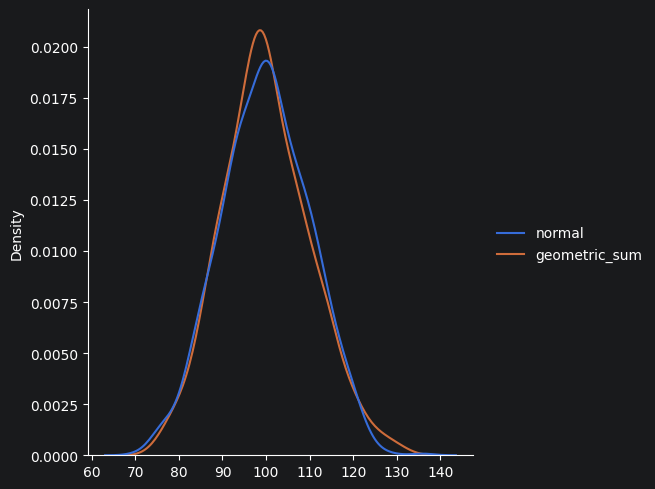

In [104]:
# CLT via summation for geometric takes the shape of the normal

data = {
    "normal" : random.normal(loc=100, scale=10, size = 1000),
    "geometric_sum" : [sum(random.geometric(p=0.5, size=50)) for _ in range(1000)]
}

sns.displot(data, kind="kde")

## Poisson Distribution
Poisson Distribution is a Discrete Distribution.

It estimates how many times an event can happen in a specified time. e.g. If someone eats twice a day what is the probability he will eat thrice?

It has two parameters:

`lam` - rate or known number of occurrences e.g. 2 for above problem.

`size` - The shape of the returned array.

In [57]:
# Generate a random 1x10 distribution for occurrence 2:
"""
The lam=2 just means on average 2 times — but each simulated day can vary around that average. Most values will cluster near 2, and rarely you get very high numbers like 6 or 7.
 the array is just simulated outcomes, not probabilities. so 1 means on time, 3 means three times a day and so one for 10 days"""
x = random.poisson(lam=2, size=10)
print(x)

[1 2 2 3 0 2 1 2 1 1]


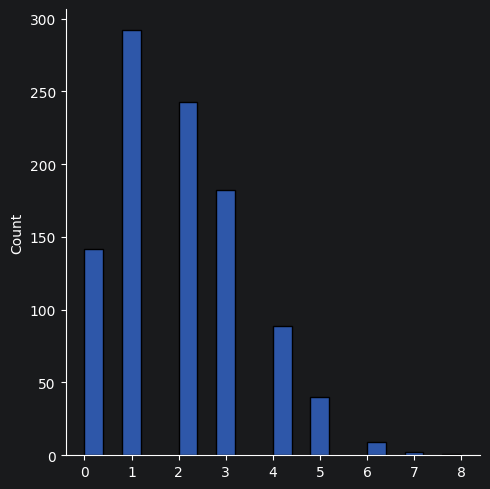

In [58]:
# Visualization of Poisson Distribution
# lam is lamda which is the teh average rate of success or mean.
sns.displot(random.poisson(lam=2, size=1000))
plt.show()

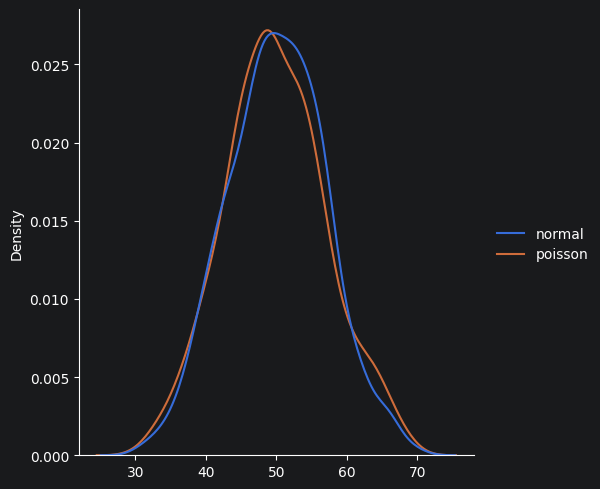

In [99]:
"""Difference Between Normal and Poisson Distribution
Normal distribution is continuous whereas poisson is discrete.
But we can see that similar to binomial for a large enough poisson distribution it will become similar to normal distribution with certain std dev and mean."""
data = {
  "normal": random.normal(loc=50, scale=7, size=1000),
  "poisson": random.poisson(lam=50, size=1000)
}
sns.displot(data, kind="kde")
plt.show()

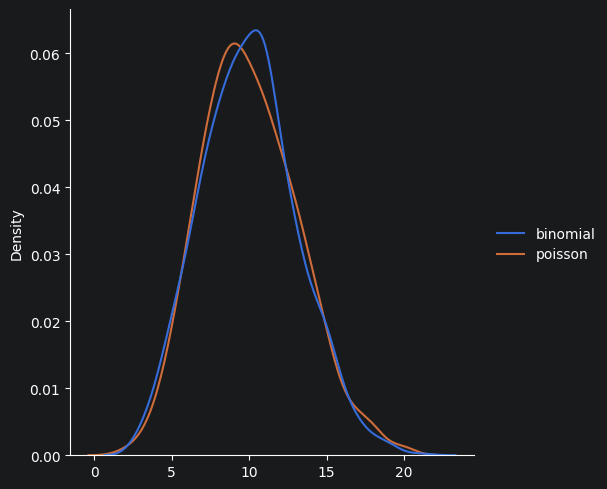

In [61]:
"""Difference Between Binomial and Poisson Distribution
Binomial distribution only has two possible outcomes, whereas poisson distribution can have unlimited possible outcomes.
But for very large n and near-zero p binomial distribution is near identical to poisson distribution such that n * p is nearly equal to lam.

binomial with huge n and tiny p ≈ poisson
Poisson is basically a shortcut for binomial when n is too large to work with practically. Instead of tracking millions of trials with tiny probability, you just use λ = n × p directly.
"""
data = {
  "binomial": random.binomial(n=1000, p=0.01, size=1000),
  "poisson": random.poisson(lam=10, size=1000)
}

sns.displot(data, kind="kde")

plt.show()

### Calculating the PMF
We use the PMF to get the probability

ach gives back the actual probability of getting exactly `k` occurrences.

So:

`random.binomial/poisson/geometric` → gives simulated values

`scipy.stats .pmf` → gives actual probabilities

In [68]:
# binomial: P(X=3) with n=10, p=0.5
# n is the total number of trials, x or k is the number of successes, and p is the probability of success in a single trial
"""
A six-sided die is rolled 12 times, what is the probability of getting a 4, five times?
"""
binom_pmf = binom.pmf(k=5, n=12, p=1/6)
print(f"{binom_pmf * 100:.2f}%")

2.84%
0.18044704431548356
0.125


In [73]:
# geometric: P(X=3) with p=0.5
# p is the probability and x or k is trial number which the first success happens.
"""
what is the probability of getting the first 6 on the fourth roll using a six-sided die?
"""
geom_pmf = geom.pmf(k=4, p=1/6)
print(f"{geom_pmf * 100:.2f}%")

9.65%


In [78]:
# poisson: P(X=3) with lam=2
# mu is the mean number of events in the interval, x or k is the exact number of events we want the probability for.
"""
A small business receives on average 12 customers a day, what is the  probability that the business will receive exactly 8 customers in one day?
"""
poisson_pmf = poisson.pmf(k=8, mu=12)
print(f"{poisson_pmf * 100:.2f}%")



6.55%


### Uniform Distribution
Used to describe probability where every event has equal chances of occuring.

E.g. Generation of random numbers.

It has three parameters:

`low` - lower bound - default 0.0

`high` - upper bound - default 1.0

`size` - The shape of the returned array

In [80]:
# Create a 2x3 uniform distribution sample:
x = random.uniform(size=(2, 3))
print(x)

[[0.20680426 0.36829611 0.00398906]
 [0.10707864 0.6093741  0.97337692]]


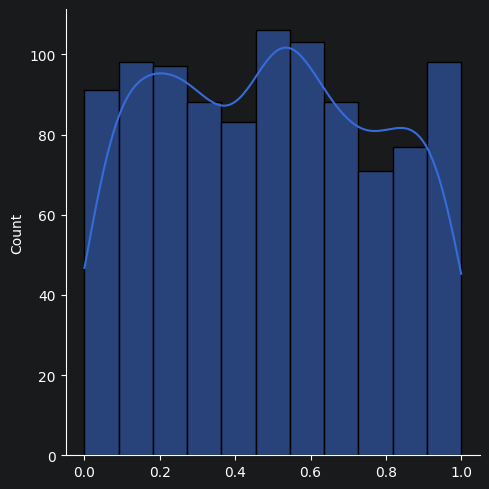

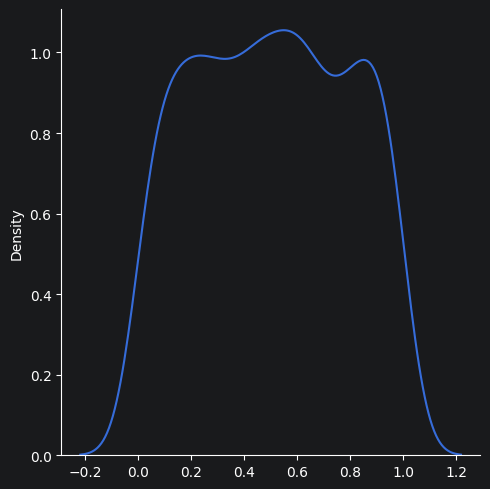

In [92]:
# Visualization of Uniform Distribution
sns.displot(random.uniform(size=1000), kde=True)
plt.show()

sns.displot(random.uniform(size=1000), kind="kde")
plt.show()

### Logistic Distribution
Logistic Distribution is used to describe growth.

Used extensively in machine learning in logistic regression, neural networks etc.

It has three parameters:

`loc` - mean, where the peak is. Default 0.

`scale` - standard deviation, the flatness of distribution. Default 1.

`size` - The shape of the returned array.

Logistic distribution looks very similar to normal distribution — bell shaped and symmetric — but with fatter tails.


In [93]:
x = random.logistic(loc=1, scale=2, size=(2, 3))
print(x)

[[ 0.17438804 -0.33183423 -0.4239192 ]
 [ 0.99826493  5.00454649  0.54600096]]


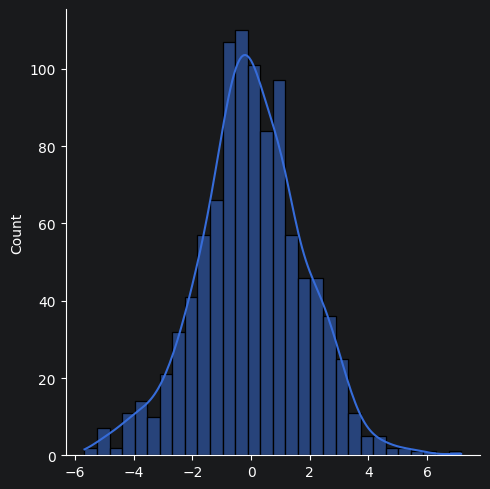

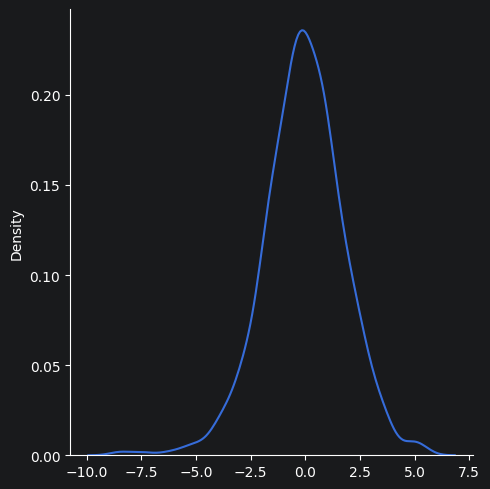

In [97]:
# Visualization of Logistic Distribution
sns.displot(random.logistic(size=1000), kde=True)
plt.show()
sns.displot(random.logistic(size=1000), kind="kde")
plt.show()

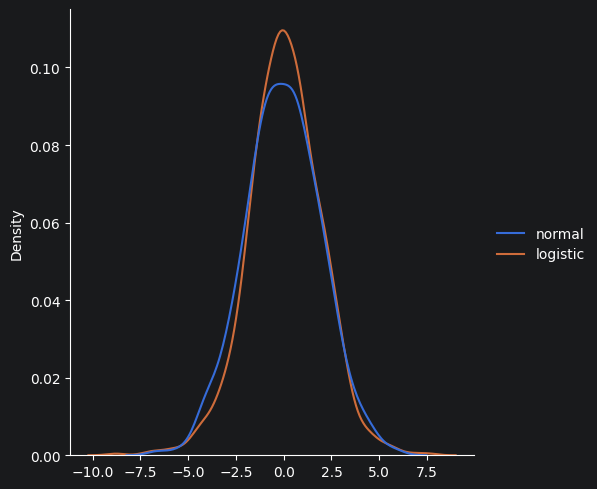

In [107]:
"""
Both distributions are near identical, but logistic distribution has more area under the tails, meaning it represents more possibility of occurrence of an event further away from mean.

For higher value of scale (standard deviation) the normal and logistic distributions are near identical apart from the peak.
"""
data = {
    "normal" : random.normal(scale=2, size=1000),
    "logistic": random.logistic(size=1000)
}
sns.displot(data, kind="kde")
plt.show()

### Multinomial Distribution
Multinomial distribution is a generalization of binomial distribution.

It describes outcomes of multi-nomial scenarios unlike binomial where scenarios must be only one of two. e.g. Blood type of a population, dice roll outcome.

It has three parameters:

`n` - number of times to run the experiment.

`pvals` - list of probabilities of outcomes (e.g. $[1/6, 1/6, 1/6, 1/6, 1/6, 1/6]$ for dice roll).

`size` - The shape of the returned array.

In [110]:
# Draw out a sample for dice roll:
x = random.multinomial(n=6, pvals=[1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
print(x)

[3 2 0 0 1 0]


### Exponential Distribution
Exponential distribution is used for describing time till next event e.g. failure/success etc.

It has two parameters:

`scale` - inverse of rate ( see lam in poisson distribution ) defaults to 1.0.

`size` - The shape of the returned array.

In [111]:
# Draw out a sample for exponential distribution with 2.0 scale with 2x3 size:
x = random.exponential(scale=2, size=(2, 3))
print(x)

[[3.96740716 4.29533769 2.87434709]
 [1.06176939 4.11819307 1.09373395]]


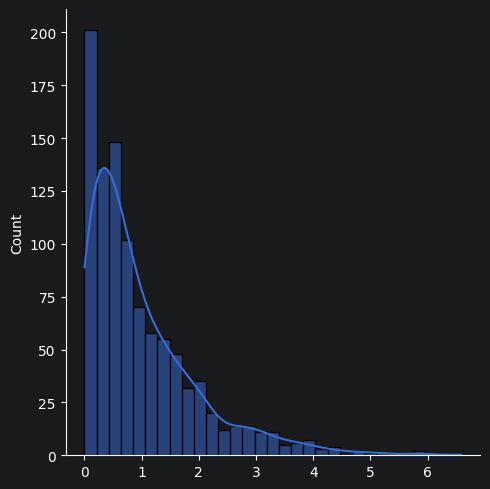

In [119]:
sns.displot(random.exponential(size=1000), kde=True)
plt.show()

### Chi Square Distribution
Chi Square distribution is used as a basis to verify the hypothesis.

It has two parameters:

`df` - (degree of freedom).

`size` - The shape of the returned array.

In [120]:
# Draw out a sample for chi squared distribution with degree of freedom 2 with size 2x3:
x = random.chisquare(df=2, size=(2, 3))
print(x)


[[0.55184731 1.4956892  0.93366284]
 [0.26023594 3.29746323 0.80952516]]


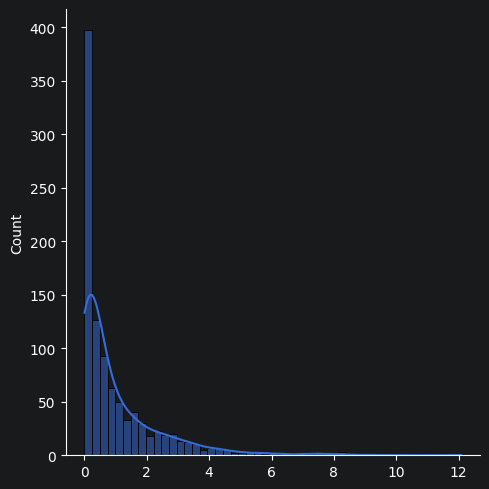

In [126]:
# Visualization of Chi Square Distribution
sns.displot(random.chisquare(df=1, size=1000), kde=True)
plt.show()

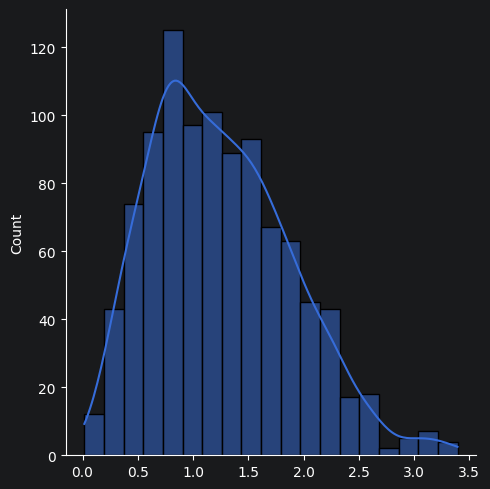

In [125]:
# Visualization of Rayleigh Distribution
sns.displot(random.rayleigh(size=1000), kde=True)

plt.show()